<a href="https://colab.research.google.com/github/thayvxss/exIntroPythonIA/blob/main/analise_USB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Análise de Dados - UBS (Google Colab)

Este notebook foi preparado para funcionar diretamente no Google Colab.


In [2]:

# Upload do arquivo CSV

from google.colab import files
uploaded = files.upload()


Saving Unidades_Basicas_Saude-UBS.csv to Unidades_Basicas_Saude-UBS.csv


In [3]:

import pandas as pd
import matplotlib.pyplot as plt


arquivo = list(uploaded.keys())[0]


df = pd.read_csv(arquivo, sep=';')


df.head()


,CNES,UF,IBGE,NOME,LOGRADOURO,BAIRRO,LATITUDE,LONGITUDE
0,23914,31,310620,CENTRO DE SAUDE JARDIM MONTANHES,RUA SAUDE,PADRE EUSTAQUIO,-19.911503,"-43,9914089036"
1,106143,26,261000,UBS FRANCISCO VIEIRA DE MELO,QUADRA 50,QUILOMBO II,-8.705590,"-35,5995386839"
2,302,26,260290,USF SANTO ESTEVAO,RUA DO CEMITERIO,PONTE DOS CARVALHOS,-8.218112,"-35,2294359"
3,405132,26,261350,UNIDADE DE SAUDE SABINO LUCAS DE BARROS,TRAVESSA SAO PAULO,VILA DELMIRO,-7.866081,"-38,7650871277"
4,881007,26,261000,UBS MARIA ALICE,QUADRA 11,QUILOMBO 2,-8.698513,"-35,6040179729"


In [4]:

# Informações gerais
print("Dimensões:", df.shape)

print("\nTipos de dados:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())


Dimensões: (47673, 8)

Tipos de dados:
CNES            int64
UF              int64
IBGE            int64
NOME           object
LOGRADOURO     object
BAIRRO         object
LATITUDE      float64
LONGITUDE      object
dtype: object

Valores nulos:
CNES             0
UF               0
IBGE             0
NOME             1
LOGRADOURO       0
BAIRRO           0
LATITUDE      1929
LONGITUDE     1928
dtype: int64


In [5]:

# Tratamento da longitude
df['LONGITUDE'] = (
    df['LONGITUDE']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df['LONGITUDE'] = pd.to_numeric(df['LONGITUDE'], errors='coerce')

df.head()


,CNES,UF,IBGE,NOME,LOGRADOURO,BAIRRO,LATITUDE,LONGITUDE
0,23914,31,310620,CENTRO DE SAUDE JARDIM MONTANHES,RUA SAUDE,PADRE EUSTAQUIO,-19.911503,-43.991409
1,106143,26,261000,UBS FRANCISCO VIEIRA DE MELO,QUADRA 50,QUILOMBO II,-8.705590,-35.599539
2,302,26,260290,USF SANTO ESTEVAO,RUA DO CEMITERIO,PONTE DOS CARVALHOS,-8.218112,-35.229436
3,405132,26,261350,UNIDADE DE SAUDE SABINO LUCAS DE BARROS,TRAVESSA SAO PAULO,VILA DELMIRO,-7.866081,-38.765087
4,881007,26,261000,UBS MARIA ALICE,QUADRA 11,QUILOMBO 2,-8.698513,-35.604018


## Quantidade de UBS por Estado

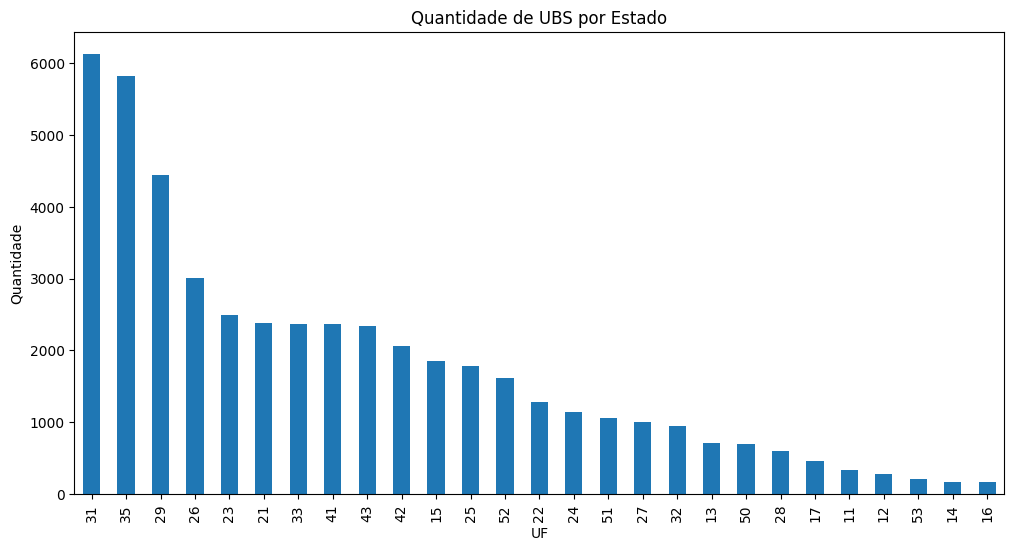

In [6]:

ubs_por_estado = df['UF'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12,6))
ubs_por_estado.plot(kind='bar')

plt.title('Quantidade de UBS por Estado')
plt.xlabel('UF')
plt.ylabel('Quantidade')

plt.show()


## Top 10 bairros com mais UBS

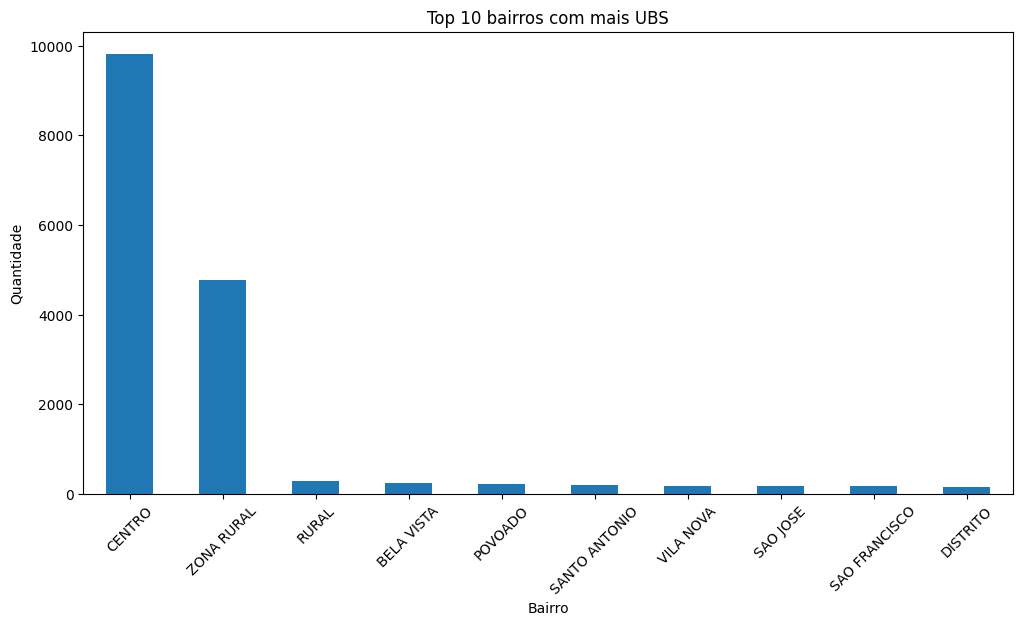

In [7]:

top_bairros = df['BAIRRO'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_bairros.plot(kind='bar')

plt.title('Top 10 bairros com mais UBS')
plt.xlabel('Bairro')
plt.ylabel('Quantidade')

plt.xticks(rotation=45)

plt.show()


## Distribuição Geográfica

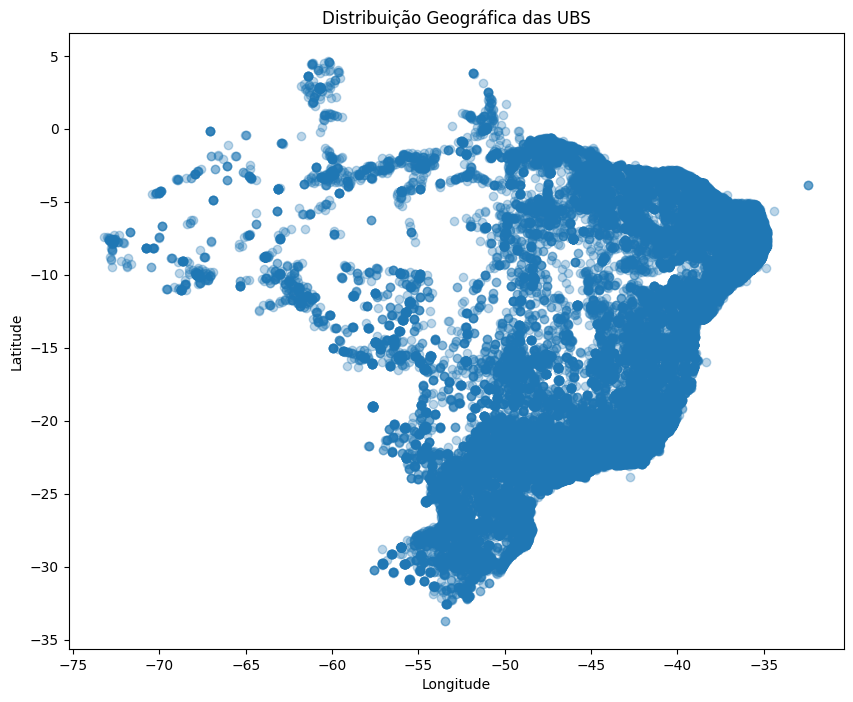

In [8]:

plt.figure(figsize=(10,8))

plt.scatter(
    df['LONGITUDE'],
    df['LATITUDE'],
    alpha=0.3
)

plt.title('Distribuição Geográfica das UBS')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()



# Conclusão

- Os estados possuem distribuições diferentes de UBS.
- Alguns bairros concentram mais unidades.
- O gráfico geográfico mostra a distribuição nacional das UBS.
